## Install libraries

In [1]:
pip install shap xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import libraries

In [3]:
import matplotlib.pylab as pl
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
import shap

# print the JS visualization code to the notebook
shap.initjs()

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import dataset

In [4]:
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

In [5]:
print(X_display)

        Age          Workclass  Education-Num       Marital Status  \
0      39.0          State-gov           13.0        Never-married   
1      50.0   Self-emp-not-inc           13.0   Married-civ-spouse   
2      38.0            Private            9.0             Divorced   
3      53.0            Private            7.0   Married-civ-spouse   
4      28.0            Private           13.0   Married-civ-spouse   
...     ...                ...            ...                  ...   
32556  27.0            Private           12.0   Married-civ-spouse   
32557  40.0            Private            9.0   Married-civ-spouse   
32558  58.0            Private            9.0              Widowed   
32559  22.0            Private            9.0        Never-married   
32560  52.0       Self-emp-inc            9.0   Married-civ-spouse   

               Occupation    Relationship    Race      Sex  Capital Gain  \
0            Adm-clerical   Not-in-family   White     Male        2174.0   
1      

In [6]:
print(y_display)

[False False False ... False False  True]


## Create test-train split

In [7]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [8]:
print(X.shape)

(32561, 12)


In [9]:
print(X_train)

        Age  Workclass  Education-Num  Marital Status  Occupation  \
12011  51.0          4           10.0               0           6   
23599  51.0          1           14.0               6          12   
23603  21.0          4           11.0               4           3   
6163   25.0          4           10.0               4          12   
14883  48.0          4           13.0               0           1   
...     ...        ...            ...             ...         ...   
5699   23.0          4            9.0               4          12   
10742  37.0          4            9.0               2           7   
16921  27.0          6            5.0               2           3   
25796  46.0          4           16.0               2          10   
28847  55.0          4           10.0               0          13   

       Relationship  Race  Sex  Capital Gain  Capital Loss  Hours per week  \
12011             0     4    0           0.0           0.0            40.0   
23599          

In [10]:
print(X_train.shape)

(26048, 12)


## Define parameters for xgboost

In [11]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}
model = xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54662
[100]	test-logloss:0.36364
[200]	test-logloss:0.31776
[300]	test-logloss:0.30052
[400]	test-logloss:0.29181
[500]	test-logloss:0.28671
[600]	test-logloss:0.28375
[700]	test-logloss:0.28163
[800]	test-logloss:0.28023
[900]	test-logloss:0.27939
[1000]	test-logloss:0.27887
[1070]	test-logloss:0.27850


## Print accuracy

In [12]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred_prob = model.predict(d_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 87.41%


## SHAP explainer

In [13]:
# This takes 5-6 minutes since we are explaining over 30
#thousand samples in a model with over a thousand trees
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

## SHAP force plot
A SHAP force plot explains why a machine-learning model made one particular prediction 

In [14]:
import plotly.io as pio

# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(explainer.expected_value, shap_values[50, :], X_display.iloc[50, :])


In [15]:
# Index of the sample you are interested in
sample_index = 49

# Get feature names
feature_names = X_display.columns

# Get SHAP values for that sample
shap_values_sample = shap_values[sample_index]

# Get the actual feature values for that sample
feature_values = X_display.iloc[sample_index]

# Print SHAP value for each feature
for name, value, shap_val in zip(feature_names, feature_values, shap_values_sample):
    if isinstance(value, (int, float)):  # If it's a number, format it
        val_str = f"{value:10.4f}"
    else:  # Otherwise just print the string
        val_str = f"{str(value):>10}"

    print(f"Feature: {name:20s} | Value: {val_str} | SHAP Value: {shap_val:+.4f}")


Feature: Age                  | Value:       29.0 | SHAP Value: -0.2395
Feature: Workclass            | Value:    Private | SHAP Value: -0.0019
Feature: Education-Num        | Value:       11.0 | SHAP Value: -0.0027
Feature: Marital Status       | Value:  Never-married | SHAP Value: -0.2543
Feature: Occupation           | Value:  Prof-specialty | SHAP Value: +0.2904
Feature: Relationship         | Value:  Not-in-family | SHAP Value: -1.1014
Feature: Race                 | Value:      White | SHAP Value: +0.0198
Feature: Sex                  | Value:       Male | SHAP Value: +0.1470
Feature: Capital Gain         | Value:        0.0 | SHAP Value: -0.1923
Feature: Capital Loss         | Value:        0.0 | SHAP Value: -0.0550
Feature: Hours per week       | Value:       43.0 | SHAP Value: +0.2865
Feature: Country              | Value:  United-States | SHAP Value: +0.0127


In [16]:
# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

## SHAP summary plot
The purpose of shap.summary_plot(shap_values, X_display, plot_type="bar") is to provide a global explanation of your model by showing which features are most important overall across the dataset.

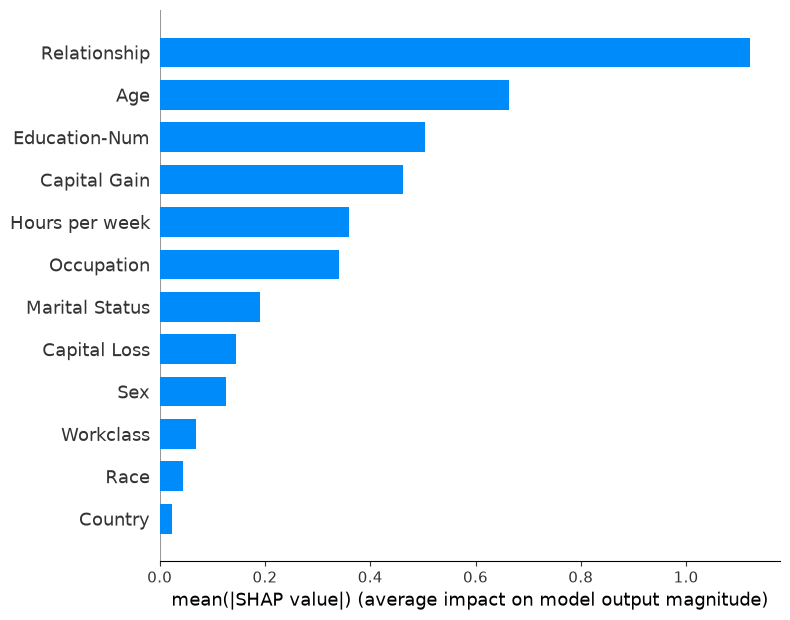

In [17]:
shap.summary_plot(shap_values, X_display, plot_type="bar")

## SHAP dependence plot
A SHAP dependence plot shows how the value of one feature affects the model prediction across many observations.

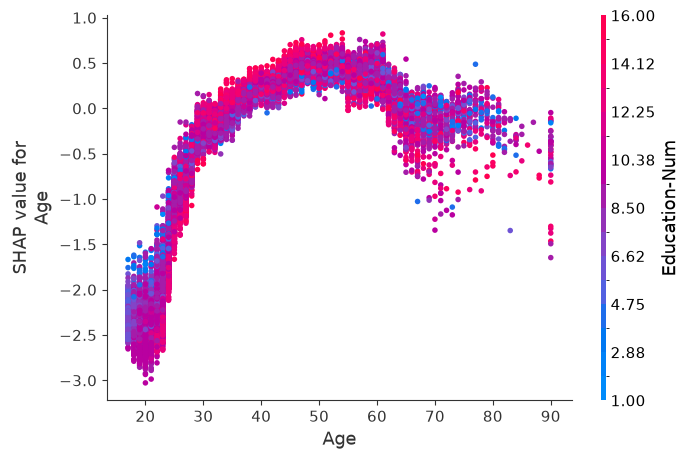

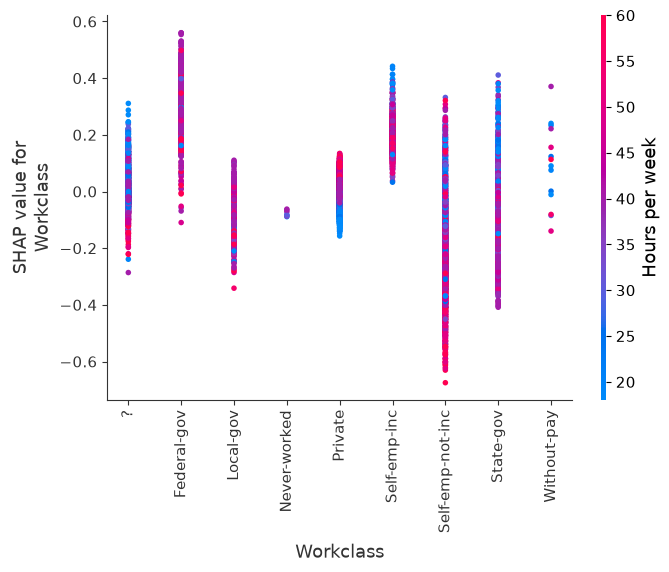

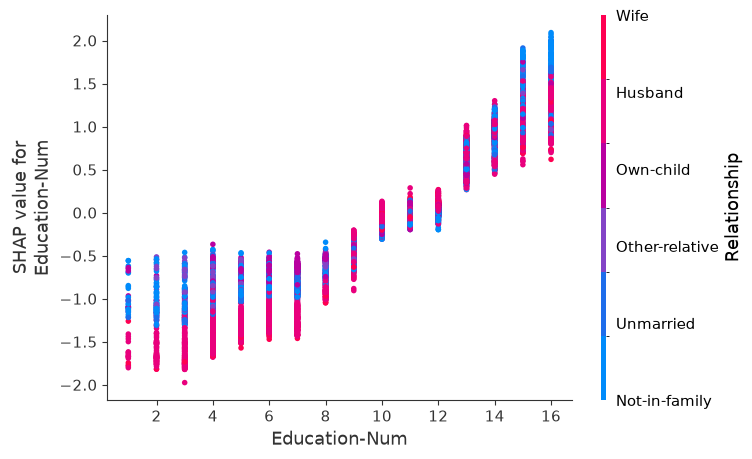

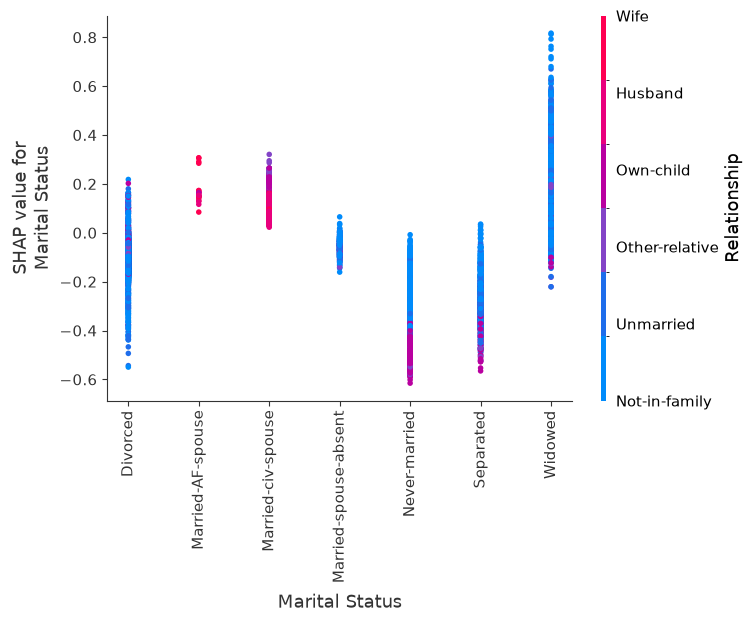

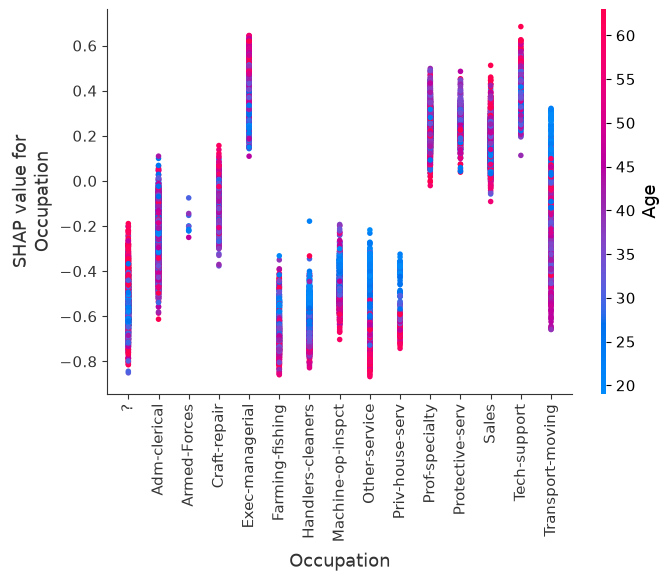

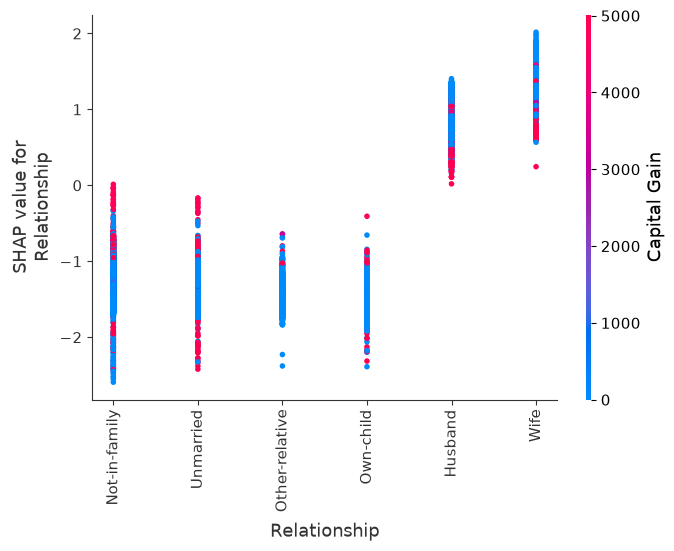

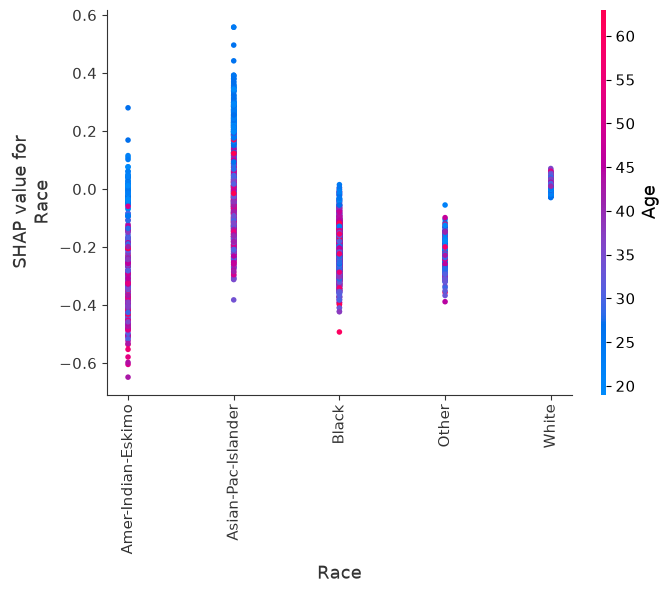

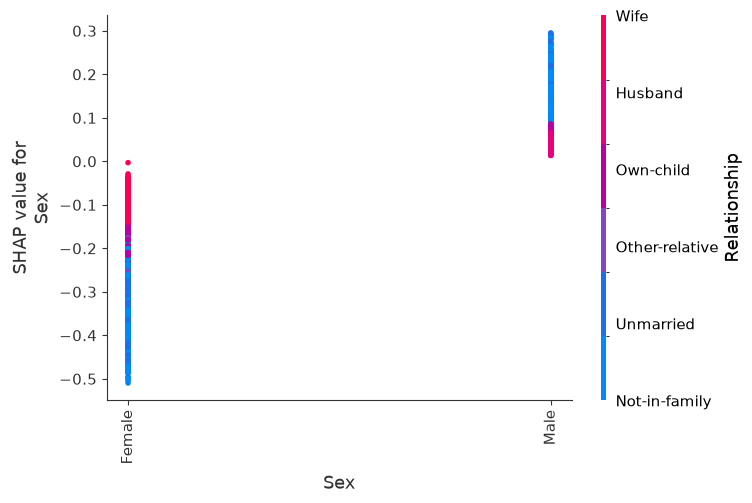

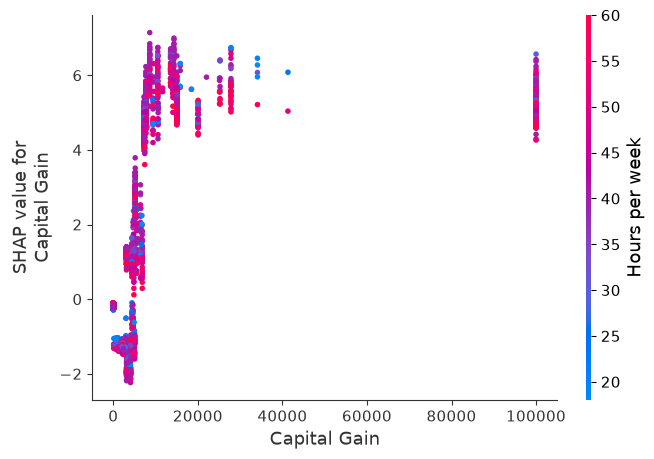

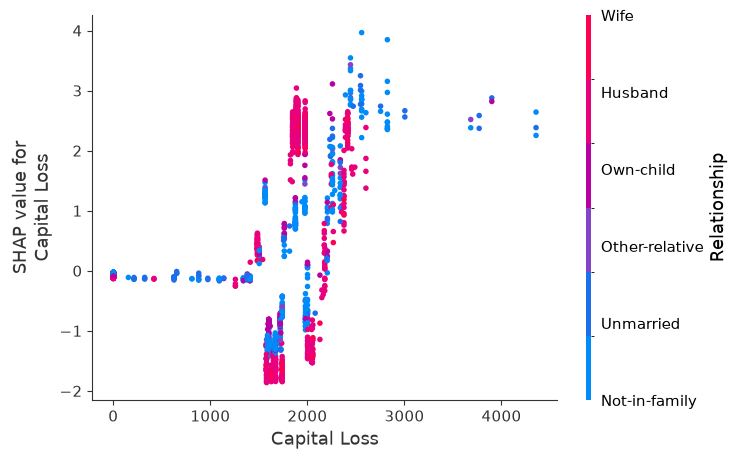

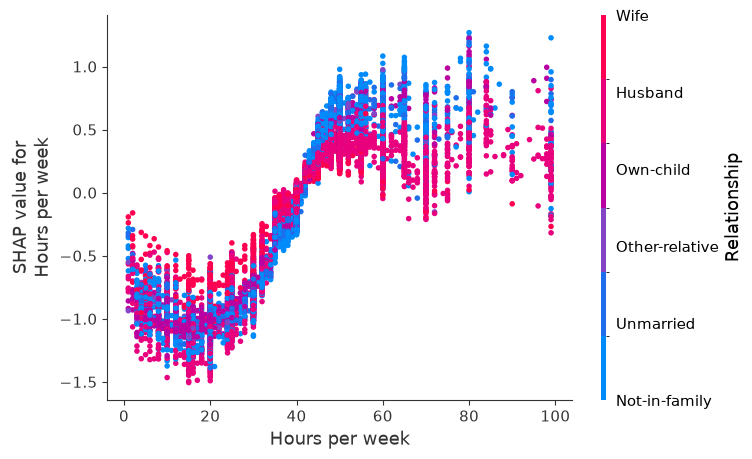

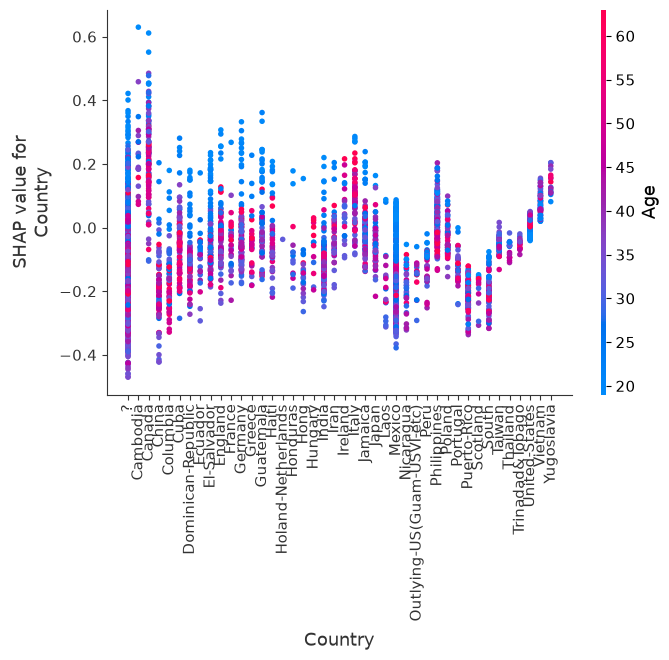

In [18]:
for name in X_train.columns:
    shap.dependence_plot(name, shap_values, X, display_features=X_display)

SHAP beeswarm plot, which is one of the most useful plots for getting a global overview of a machine-learning model.

It answers two questions at the same time:

Which features are most important overall?
For each feature, do its values push predictions higher or lower?

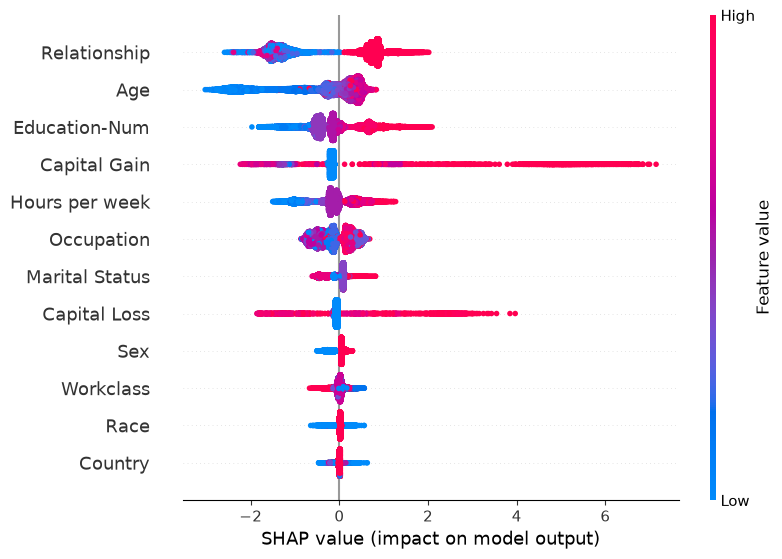

In [19]:
shap_exp = explainer(X)

shap.plots.beeswarm(
    shap_exp,
    max_display=15
)

A SHAP waterfall plot explains why the model made a particular prediction for one observation.

The easiest way to understand it is:

Start with the base value → add/subtract each feature's SHAP contribution → arrive at the final prediction \(f(x)\).

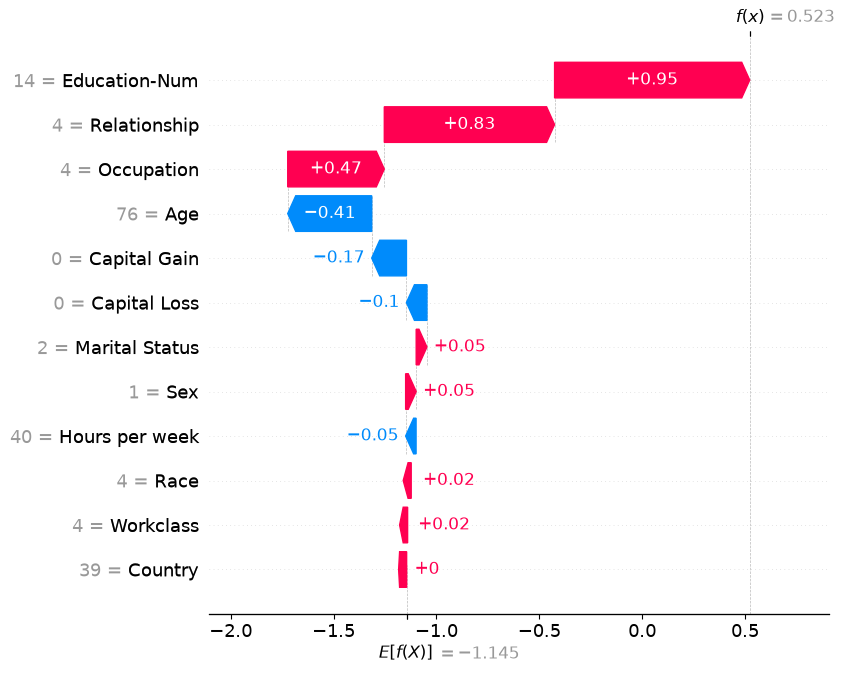

In [20]:
# 4. Waterfall plot
shap.plots.waterfall(shap_exp[100], max_display=15)

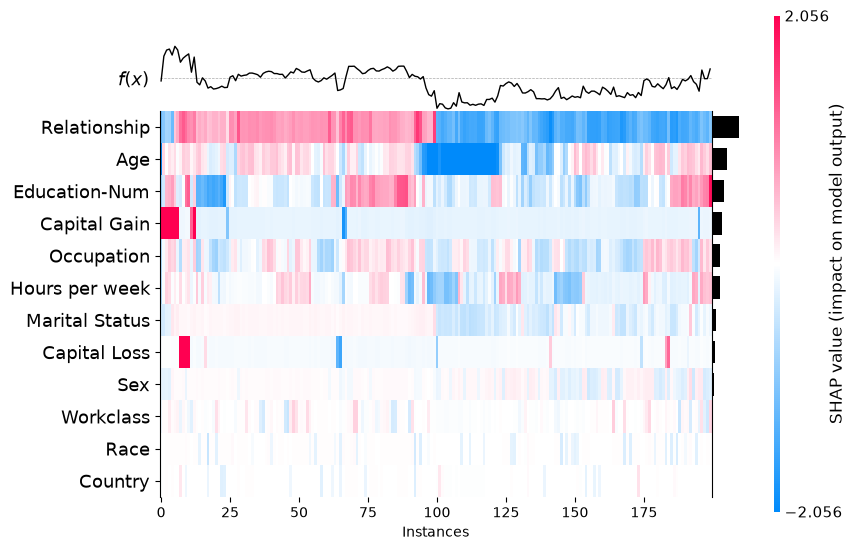

<Axes: xlabel='Instances'>

In [21]:
# 3. Heatmap
shap.plots.heatmap(shap_exp[:200], max_display=15)

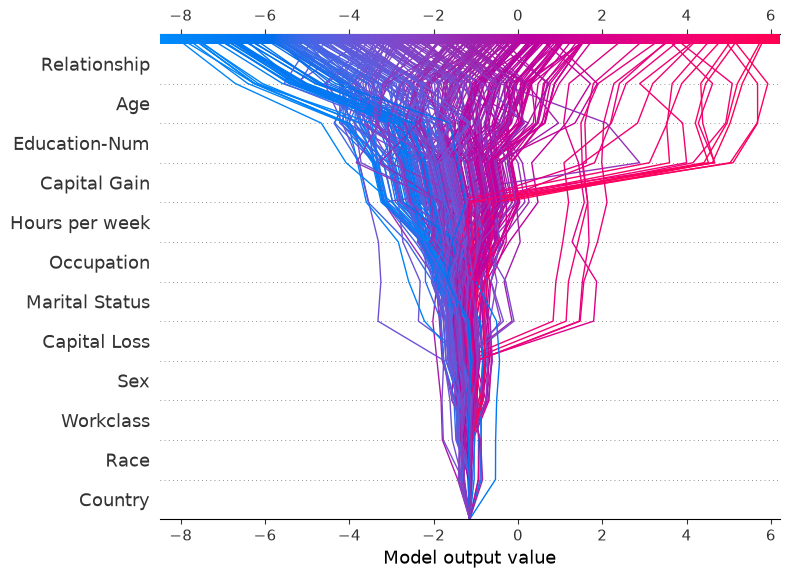

In [22]:
import shap
import matplotlib.pyplot as plt

# Create a smaller sample for a clear plot
X_sample = X.iloc[:300]
shap_sample = shap_values[:300]

shap.decision_plot(
    explainer.expected_value,
    shap_sample,
    X_sample
)



# Explainable AI Using SHAP

### Dataset

Use the **Breast Cancer Wisconsin Diagnostic Dataset** available through `scikit-learn` to build a machine learning model for classifying breast tumours as **malignant or benign** based on their measured characteristics.

### Objective

In this experiment, apply **SHAP (SHapley Additive exPlanations)** as an Explainable AI (XAI) technique to understand how individual features contribute to the predictions made by the trained machine learning model.

The following SHAP visualizations should be used:

* **SHAP Bar Plot** – to identify the globally most important features.
* **SHAP Summary/Beeswarm Plot** – to understand the direction, magnitude, and distribution of feature effects.
* **SHAP Waterfall Plot** – to explain the contribution of features for an individual prediction.
* **SHAP Dependence Plot** – to understand how a feature affects model predictions across different feature values.
* **SHAP Force Plot** – to visualize how features push an individual prediction toward malignant or benign.

---

### Task 1: Load and Prepare the Dataset

* Load the Breast Cancer Wisconsin Diagnostic dataset using `sklearn.datasets`.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Display the feature names.
* Display the target classes.
* Display descriptive statistics of the input features.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

**Comment:**

Explain the structure of the dataset, the target variable, and the purpose of separating the data into training and testing sets.

---

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm for classifying breast tumours.
* Train the model using the training dataset.
* Generate predictions for the test dataset.
* Generate prediction probabilities.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

Use a classification model such as **Random Forest Classifier**.

**Comment:**

Explain why the selected machine learning algorithm is appropriate for this dataset and discuss the obtained model performance.

---

### Task 3: Create a SHAP Explainer

* Import the SHAP library.
* Create an appropriate SHAP explainer for the trained machine learning model.
* Calculate the SHAP values for the test dataset.
* Examine the shape of the generated SHAP values.

**Comment:**

Explain:

1. What SHAP stands for.
2. What a SHAP value represents.
3. What a positive SHAP value indicates.
4. What a negative SHAP value indicates.
5. What a SHAP value close to zero means.
6. Why SHAP can be used to explain machine learning predictions.

---

### Task 4: SHAP Feature Importance – Bar Plot

Generate a **SHAP bar plot** showing the global importance of the input features.

* Calculate the mean absolute SHAP value for each feature.
* Rank the features according to their SHAP importance.
* Display the most important features using a bar chart.

**Comment:**

Identify the **top five most important features** and explain how the SHAP bar plot helps in understanding the **global behaviour** of the trained model.

---

### Task 5: SHAP Summary / Beeswarm Plot

Generate a **SHAP summary (beeswarm) plot** for the input features.

Use the plot to investigate:

* Feature importance
* SHAP value magnitude
* Positive and negative feature effects
* High and low feature values
* Distribution of SHAP values

**Comment:**

For the three most important features, explain:

1. How high feature values affect the prediction.
2. How low feature values affect the prediction.
3. Whether the feature generally pushes the prediction toward malignant or benign.
4. Whether the relationship appears linear or nonlinear.

---

### Task 6: SHAP Waterfall Plot

Select at least **one individual tumour sample** from the test dataset.

Generate a **SHAP waterfall plot** to explain its prediction.

Display:

* The base/expected value.
* Individual feature contributions.
* Features that push the prediction toward malignant.
* Features that push the prediction toward benign.
* The final model prediction.

**Comment:**

Explain how each important feature contributes to the prediction of the selected tumour sample.

---

### Task 7: SHAP Force Plot

Generate a **SHAP force plot** for the same individual sample used in Task 6.

**Comment:**

Explain:

1. Which features push the prediction toward malignant?
2. Which features push the prediction toward benign?
3. Which feature has the largest contribution?
4. How does the force plot represent the movement from the base value to the final prediction?

Compare the force plot with the waterfall plot.

---

### Task 8: SHAP Dependence Plot

Generate SHAP dependence plots for three important features identified from the SHAP analysis.

For example:

* `mean radius`
* `mean perimeter`
* `mean concavity`

**Comment:**

For each feature, explain:

1. How the feature value affects the SHAP value.
2. Whether increasing the feature increases or decreases the prediction.
3. Whether the relationship is linear or nonlinear.
4. Whether the effect changes at different feature values.
5. Whether any possible feature interaction can be observed.

---

### Task 9: Compare SHAP Explanations for Different Samples

Select at least **three different tumour samples** from the test dataset.

Generate SHAP explanations for each sample.

Compare their predictions and feature contributions.

**Comment:**

Explain:

1. Why can the same feature have different SHAP values for different samples?
2. Which features are consistently important?
3. Which features show different effects across samples?
4. How does this demonstrate the difference between **global and local explanations**?

---

### Task 10: Compare SHAP with Model Feature Importance

Calculate the built-in feature importance of the Random Forest model.

Compare it with the SHAP feature importance obtained in Task 4.

**Comment:**

Discuss:

1. Are the top-ranked features the same?
2. If there are differences, why might they occur?
3. What additional information does SHAP provide?
4. Why is feature importance alone insufficient for understanding individual predictions?

---

### Task 11: Compare Different SHAP Plots

Compare the following SHAP visualizations:

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment:**

Explain why different SHAP plots are required to obtain a complete understanding of the machine learning model.

---

### Task 12: Global vs Local Explainability

Using the SHAP plots generated in the previous tasks, explain the difference between:

**Global Explanation**

> How does the model generally classify breast tumour samples?

**Local Explanation**

> Why did the model classify this particular tumour sample as malignant or benign?

**Comment:**

Use examples from the SHAP bar/beeswarm plots and waterfall/force plots to support your explanation.

---

### Task 13: Analyse Feature Interactions

Use SHAP dependence analysis to investigate whether two important features interact with each other.

**Comment:**

Discuss:

1. Which two features appear to interact?
2. How does one feature influence the effect of another feature?
3. Why are feature interactions important for understanding model behaviour?
4. Can the effect of a feature change depending on the value of another feature?

---

### Task 14: SHAP-Based Model Analysis

Based on all the SHAP visualizations, identify:

* The five most important features.
* The feature that has the strongest positive contribution toward the predicted class.
* The feature that has the strongest negative contribution.
* Features with nonlinear effects.
* Features that show possible interactions.
* Features that consistently influence individual predictions.

**Comment:**

Explain how the SHAP analysis provides a deeper understanding of the model than simply looking at classification accuracy.

---

### Task 15: Explain a Misclassified Sample

Identify at least **one incorrectly classified sample** from the test dataset.

Generate a SHAP waterfall plot for the misclassified sample.

**Comment:**

Explain:

1. What was the actual class?
2. What class did the model predict?
3. Which features contributed most strongly to the incorrect prediction?
4. Were there features pushing the prediction toward the correct class?
5. What does the SHAP explanation reveal about the model's error?

---

### Task 16: Explain a Correctly Classified Sample

Select one correctly classified sample from the test dataset.

Generate a SHAP waterfall plot.

Compare this explanation with the misclassified sample from Task 15.

**Comment:**

Discuss how the feature contributions differ between the correctly classified and incorrectly classified samples.

---

### Final Observation

Write a short conclusion explaining how **SHAP provides both global and local explanations** of a trained machine learning model for breast cancer classification.

Your conclusion should discuss:

* Overall feature importance.
* Direction of feature effects.
* Individual feature contributions.
* Differences between individual tumour samples.
* Feature interactions.
* Correct and incorrect predictions.
* Global versus local explanations.
* The usefulness and limitations of SHAP for interpreting machine learning models.
* Why human/domain-expert validation is important when interpreting XAI results in healthcare.

In [23]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Breast Cancer Wisconsin Diagnostic dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Display first five records
print("First 5 Records:")
display(X.head())

# Dataset dimensions
print("\nDataset Dimensions:")
print(X.shape)

# Data types
print("\nData Types:")
print(X.dtypes)

# Missing values
print("\nMissing Values:")
print(X.isnull().sum().sum())

# Feature names
print("\nFeature Names:")
print(data.feature_names)

# Target classes
print("\nTarget Classes:")
print(data.target_names)

# Descriptive statistics
print("\nDescriptive Statistics:")
display(X.describe())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

First 5 Records:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Dataset Dimensions:
(569, 30)

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst conca

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Training Set Shape: (455, 30)
Testing Set Shape: (114, 30)


In [24]:
# TASK 2: Train a Machine Learning Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Create Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred = rf_model.predict(X_test)

# Generate prediction probabilities
y_pred_proba = rf_model.predict_proba(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("Random Forest Model Performance")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nPrediction probabilities for first 5 test samples:")
print(y_pred_proba[:5])

Random Forest Model Performance
Accuracy : 0.9561
ROC-AUC  : 0.9937

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[39  3]
 [ 2 70]]

Prediction probabilities for first 5 test samples:
[[1.   0.  ]
 [0.   1.  ]
 [0.88 0.12]
 [0.72 0.28]
 [0.99 0.01]]


In [25]:
# TASK 3: Create a SHAP Explainer

import shap

# Create SHAP Tree Explainer for the trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test dataset
shap_values = explainer(X_test)

# Examine the shape of SHAP values
print("SHAP values shape:", shap_values.values.shape)

# Display basic information
print("Number of test samples:", X_test.shape[0])
print("Number of features:", X_test.shape[1])

SHAP values shape: (114, 30, 2)
Number of test samples: 114
Number of features: 30


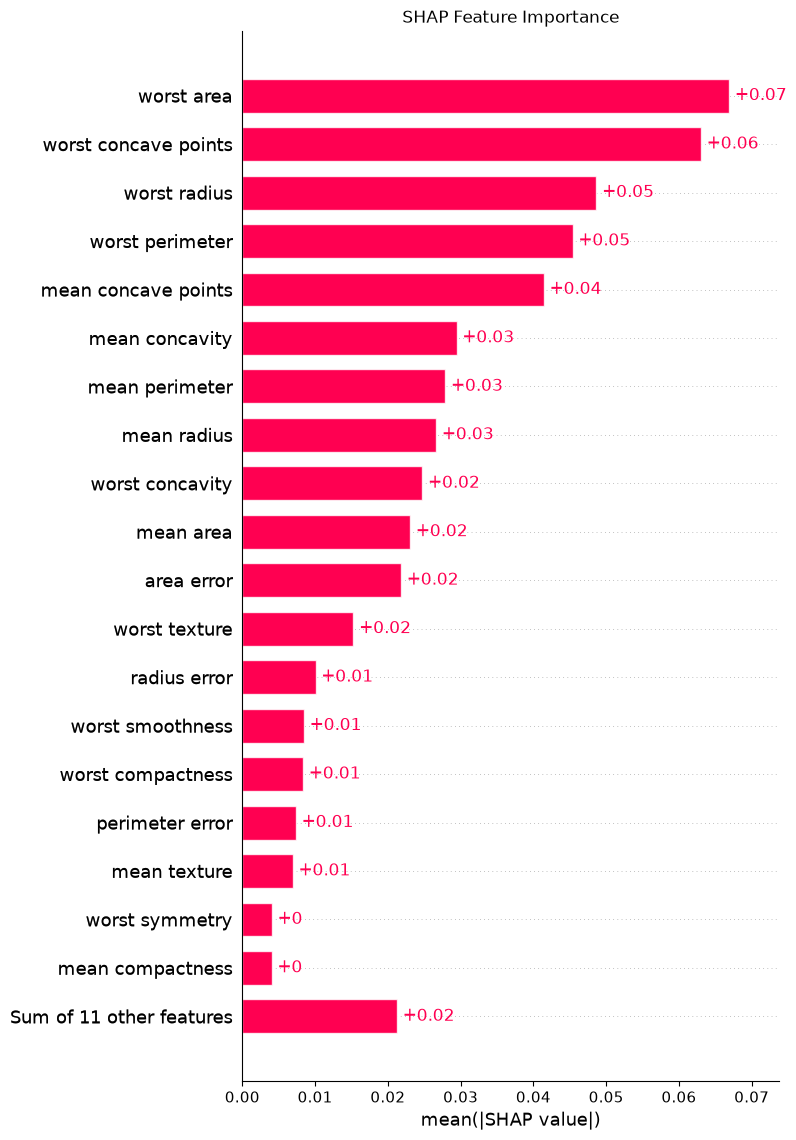

Top 5 Most Important Features:


,Feature,Mean Absolute SHAP
23,worst area,0.066893
27,worst concave points,0.063026
20,worst radius,0.048655
22,worst perimeter,0.045389
7,mean concave points,0.041439


In [26]:
# TASK 4: SHAP Feature Importance – Bar Plot

import numpy as np
import matplotlib.pyplot as plt
import shap

# Select SHAP values for the benign class (class 1)
if shap_values.values.ndim == 3:
    shap_values_class = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=X_test.values,
        feature_names=X_test.columns.tolist()
    )
else:
    shap_values_class = shap_values

# Generate SHAP bar plot
plt.figure()
shap.plots.bar(shap_values_class, max_display=20, show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values_class.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values("Mean Absolute SHAP", ascending=False)

print("Top 5 Most Important Features:")
display(feature_importance.head(5))

SHAP feature importance is measured using the mean absolute SHAP value across all test samples. Features with larger values have a greater overall influence on the model's predictions. The bar plot shows global feature importance but does not show whether a feature increases or decreases the prediction.

The SHAP bar plot shows the global importance of features based on their mean absolute SHAP values. Worst area, worst concave points, worst radius, worst perimeter, and mean concave points are the five most influential features in the model. These features have the greatest overall impact on the model's predictions across the test dataset. The bar plot shows the magnitude of importance but does not indicate the direction of the effect.

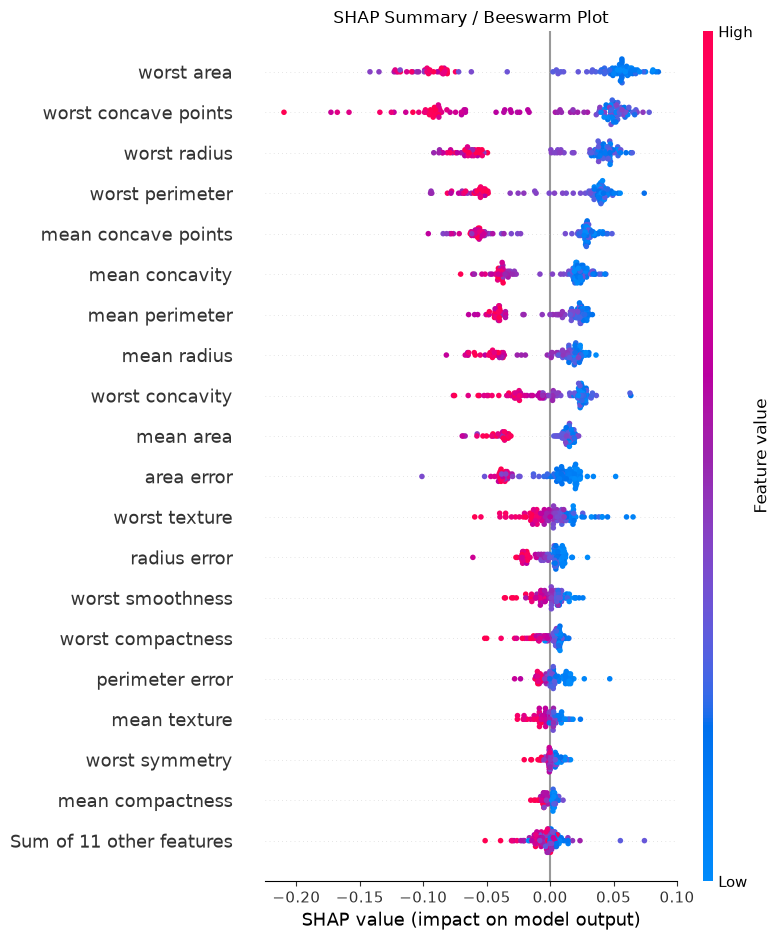

In [27]:
# TASK 5: SHAP Summary / Beeswarm Plot

import shap
import matplotlib.pyplot as plt

# Generate SHAP summary / beeswarm plot
plt.figure()
shap.plots.beeswarm(shap_values_class, max_display=20, show=False)
plt.title("SHAP Summary / Beeswarm Plot")
plt.tight_layout()
plt.show()

The SHAP beeswarm plot shows both the importance and direction of each feature. Features near the top are more important, while the horizontal position shows whether their SHAP contribution pushes the prediction toward or away from the explained class. The colour represents the feature value, with high and low values shown using different colours. The spread of points indicates how the effect of a feature varies across individual samples.

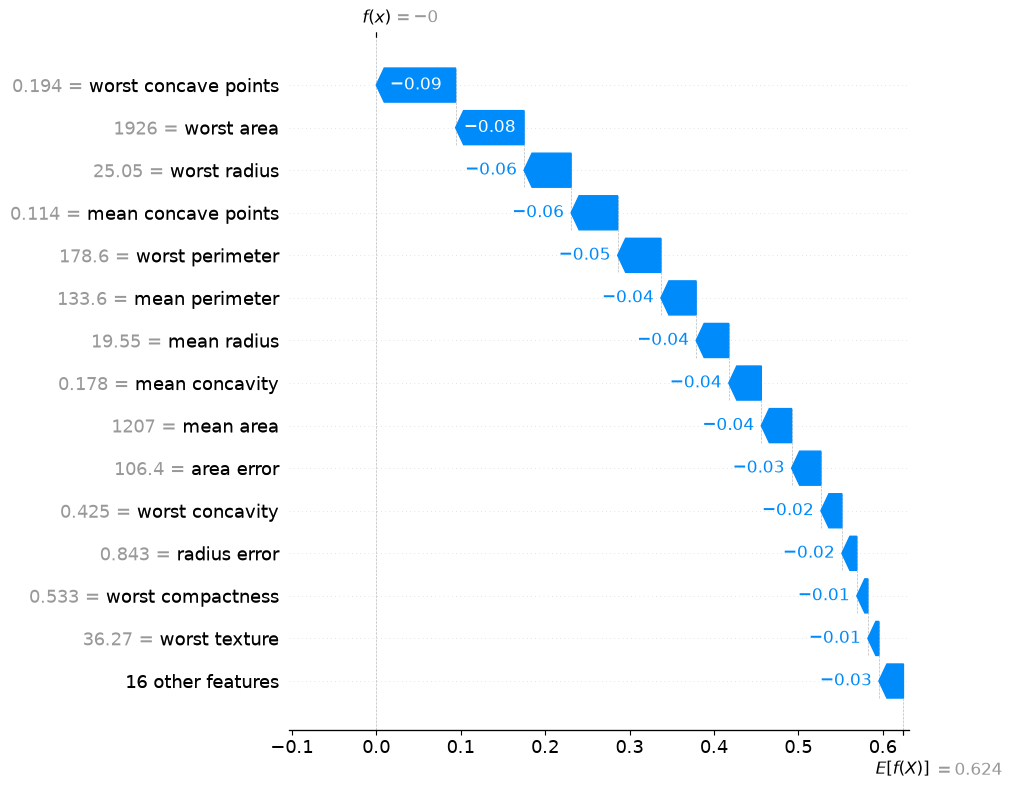

Selected Test Sample: 0
Actual Class: malignant
Predicted Class: malignant
Prediction Probability: [1. 0.]


In [28]:
# TASK 6: SHAP Waterfall Plot

# Select one individual test tumour sample
sample_index = 0

# Generate waterfall plot for the selected sample
shap.plots.waterfall(
    shap_values_class[sample_index],
    max_display=15
)

# Display the actual and predicted class
actual_class = data.target_names[y_test.iloc[sample_index]]
predicted_class = data.target_names[y_pred[sample_index]]

print("Selected Test Sample:", sample_index)
print("Actual Class:", actual_class)
print("Predicted Class:", predicted_class)
print("Prediction Probability:", y_pred_proba[sample_index])

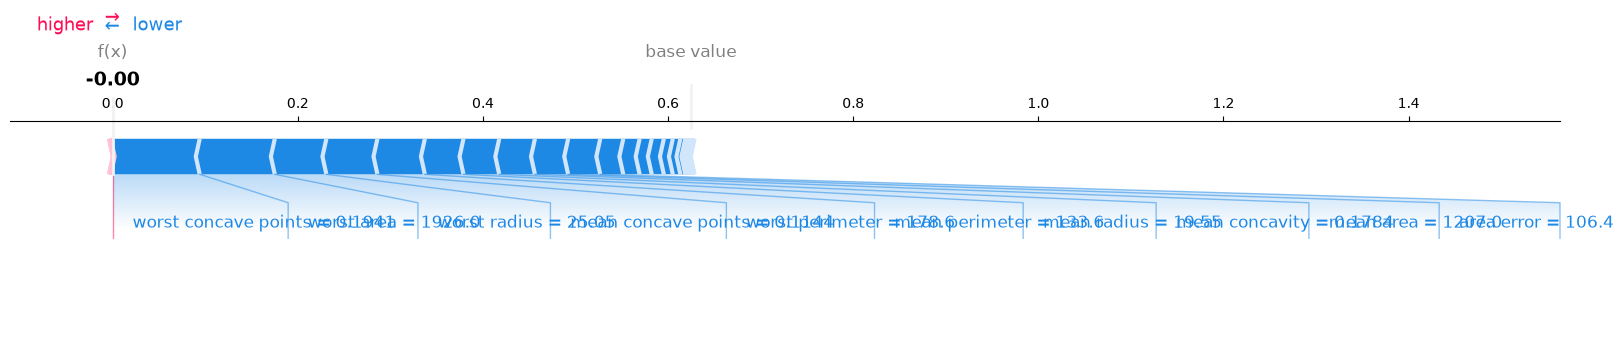

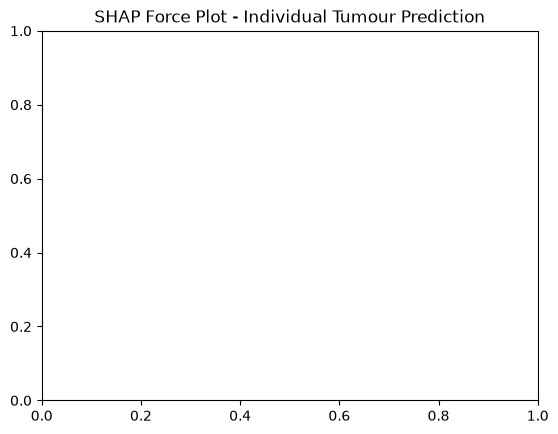

Selected Test Sample: 0
Actual Class: malignant
Predicted Class: malignant


In [29]:
# TASK 7: SHAP Force Plot

# Select the same sample used in Task 6
sample_index = 0

# Generate SHAP force plot
shap.initjs()

force_plot = shap.force_plot(
    shap_values_class.base_values[sample_index],
    shap_values_class.values[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

plt.title("SHAP Force Plot - Individual Tumour Prediction")
plt.show()

print("Selected Test Sample:", sample_index)
print("Actual Class:", data.target_names[y_test.iloc[sample_index]])
print("Predicted Class:", data.target_names[y_pred[sample_index]])

<Figure size 640x480 with 0 Axes>

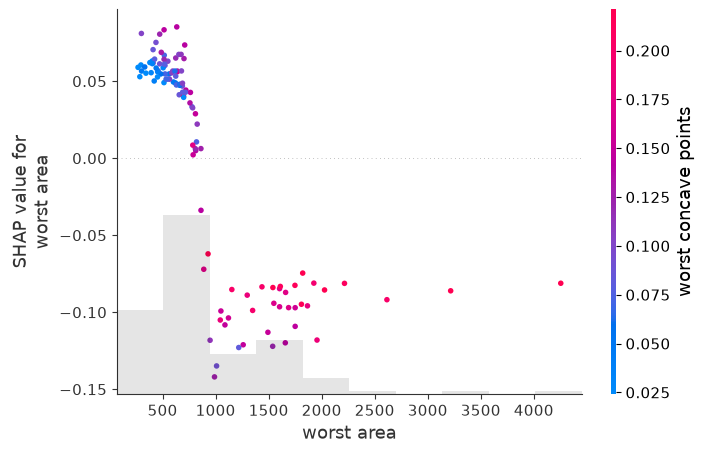

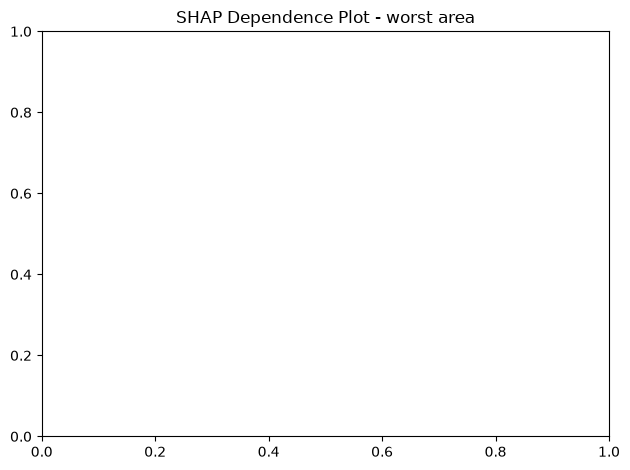

<Figure size 640x480 with 0 Axes>

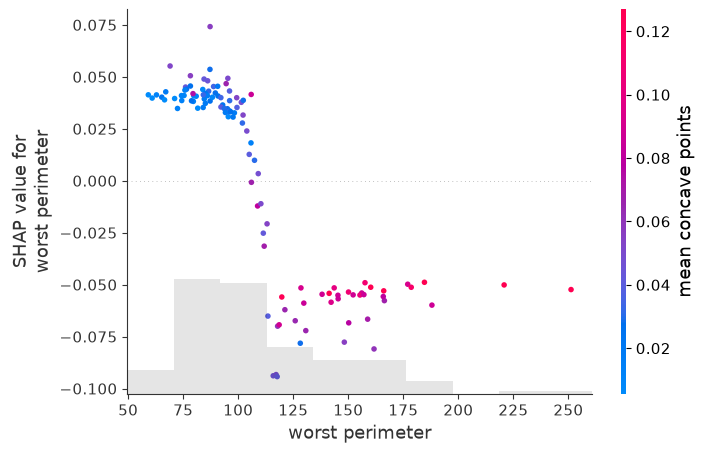

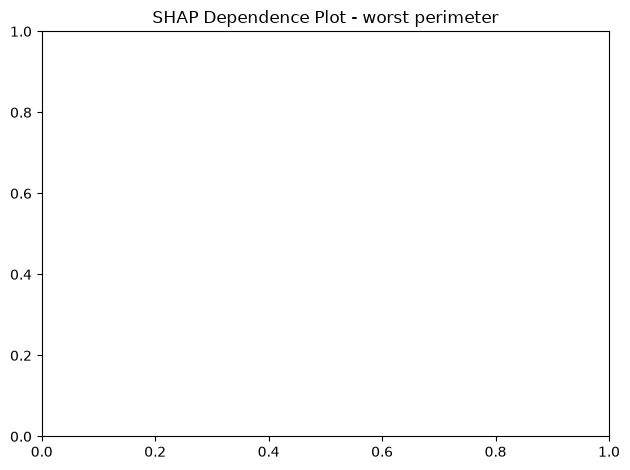

<Figure size 640x480 with 0 Axes>

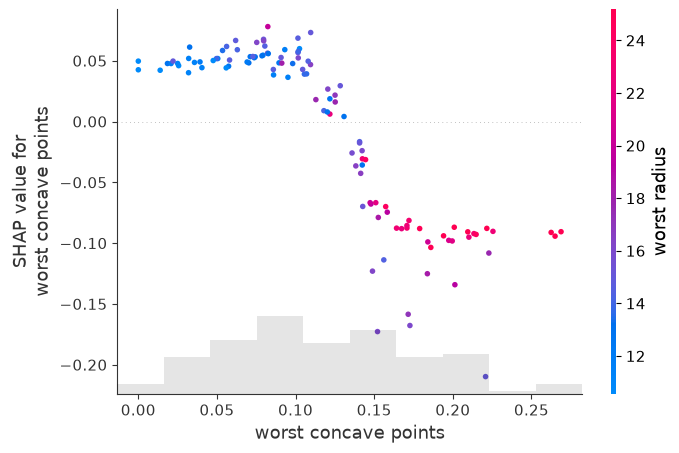

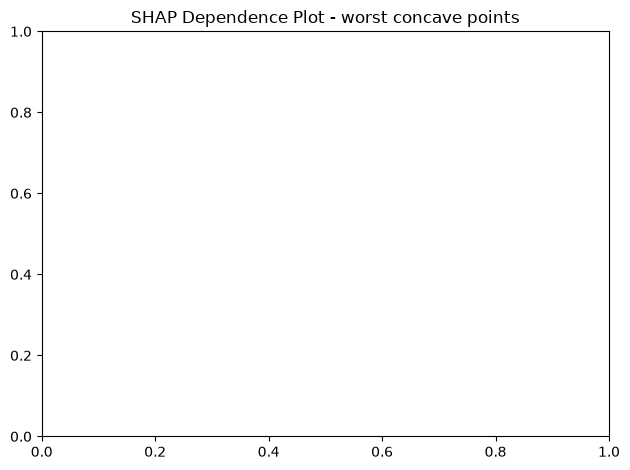

In [30]:
# TASK 8: SHAP Dependence Plot

import shap
import matplotlib.pyplot as plt

# Three important features from Task 4
important_features = [
    "worst area",
    "worst perimeter",
    "worst concave points"
]

# Generate dependence plots
for feature in important_features:
    plt.figure()
    shap.plots.scatter(
        shap_values_class[:, feature],
        color=shap_values_class
    )
    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()
    plt.show()

Sample 0
Actual Class: malignant
Predicted Class: malignant
Prediction Probability: [1. 0.]


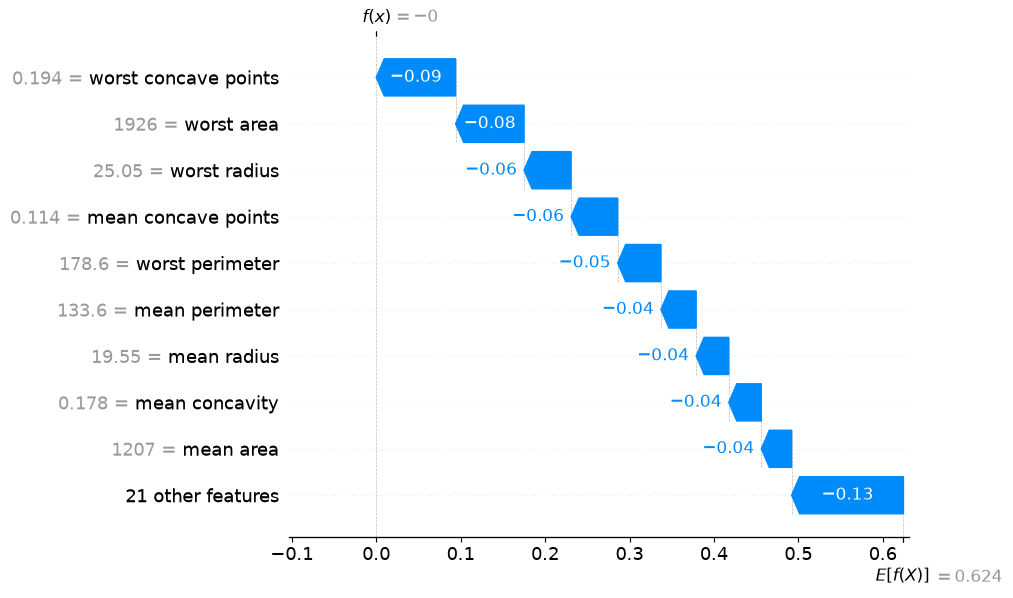

Sample 1
Actual Class: benign
Predicted Class: benign
Prediction Probability: [0. 1.]


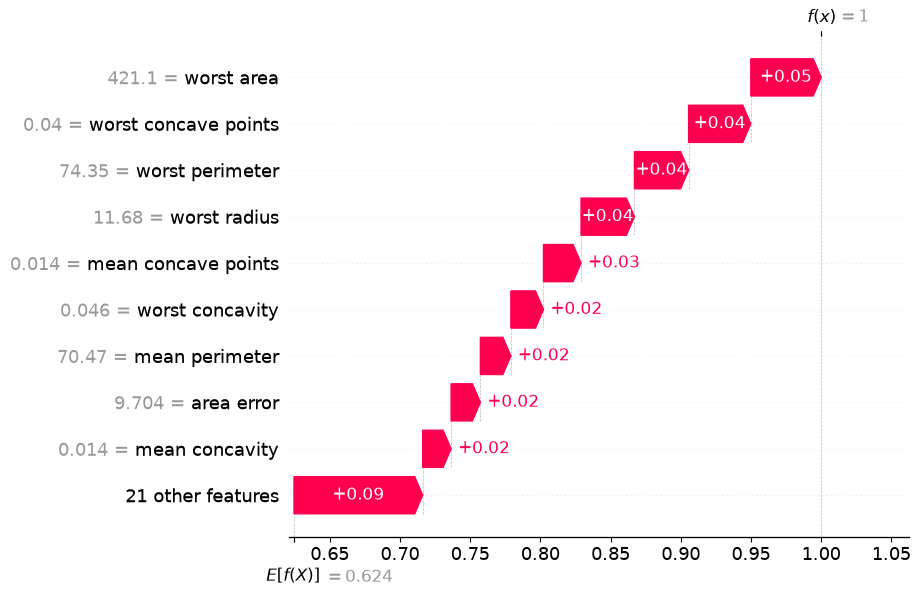

Sample 2
Actual Class: malignant
Predicted Class: malignant
Prediction Probability: [0.88 0.12]


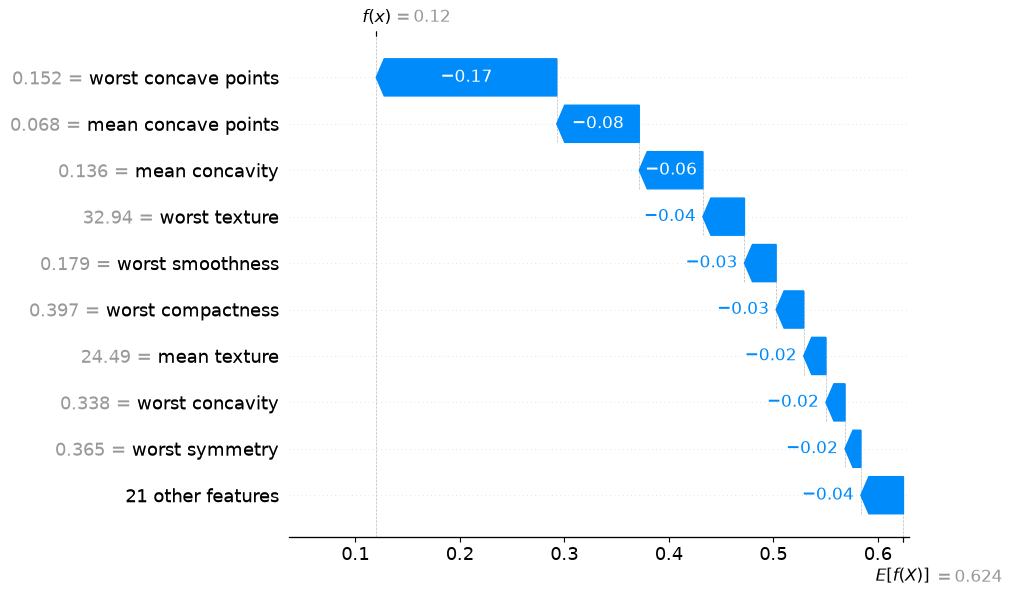

In [31]:
# TASK 9: Compare SHAP Explanations for Different Samples

# Select three test tumour samples
sample_indices = [0, 1, 2]

# Generate SHAP waterfall plots for the three samples
for sample_index in sample_indices:
    print(f"Sample {sample_index}")
    print("Actual Class:", data.target_names[y_test.iloc[sample_index]])
    print("Predicted Class:", data.target_names[y_pred[sample_index]])
    print("Prediction Probability:", y_pred_proba[sample_index])

    shap.plots.waterfall(
        shap_values_class[sample_index],
        max_display=10
    )

In [32]:
# TASK 10: Compare SHAP with Model Feature Importance

# Get Random Forest built-in feature importance
rf_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Random Forest Importance": rf_model.feature_importances_,
    "Mean Absolute SHAP": mean_abs_shap
})

# Sort by Random Forest feature importance
rf_importance = rf_importance.sort_values(
    "Random Forest Importance",
    ascending=False
)

print("Top 10 Features - Random Forest vs SHAP")
display(rf_importance.head(10))

Top 10 Features - Random Forest vs SHAP


,Feature,Random Forest Importance,Mean Absolute SHAP
23,worst area,0.140016,0.066893
27,worst concave points,0.129530,0.063026
20,worst radius,0.097696,0.048655
7,mean concave points,0.090885,0.041439
22,worst perimeter,0.072226,0.045389
2,mean perimeter,0.069574,0.027883
0,mean radius,0.068676,0.026630
6,mean concavity,0.057638,0.029439
3,mean area,0.049172,0.023054
26,worst concavity,0.034340,0.024727


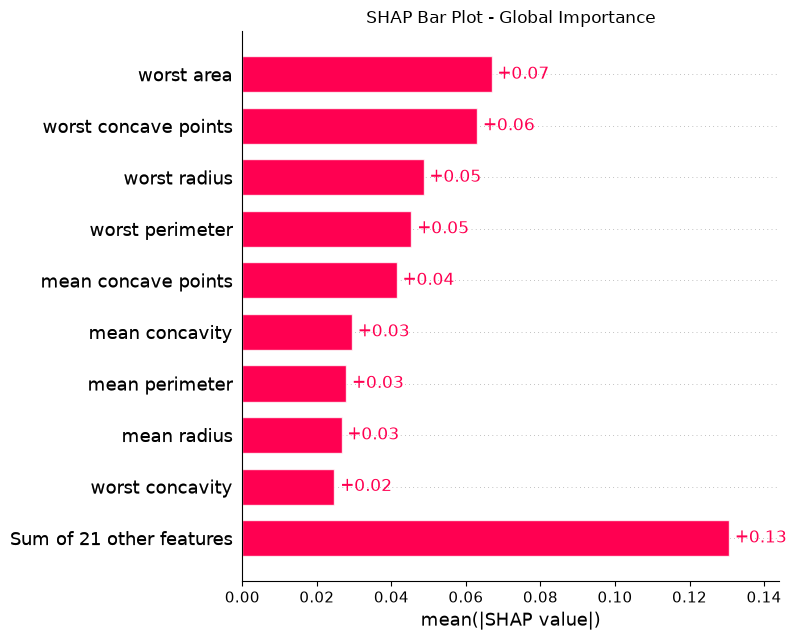

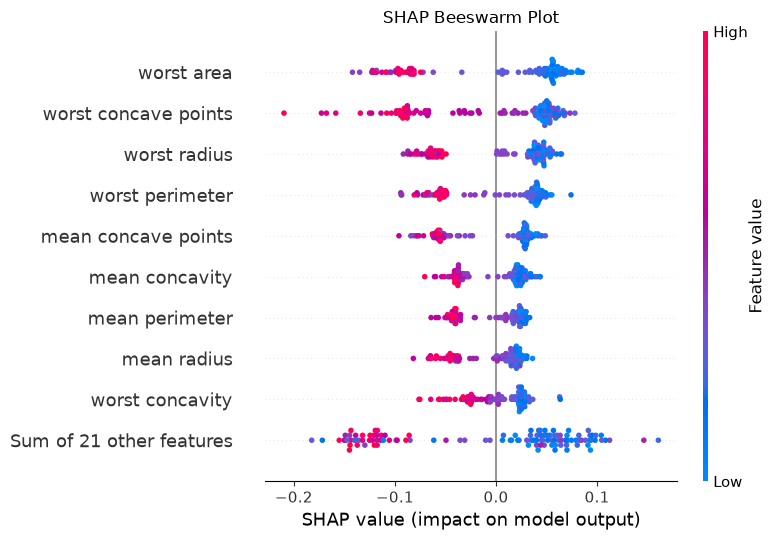

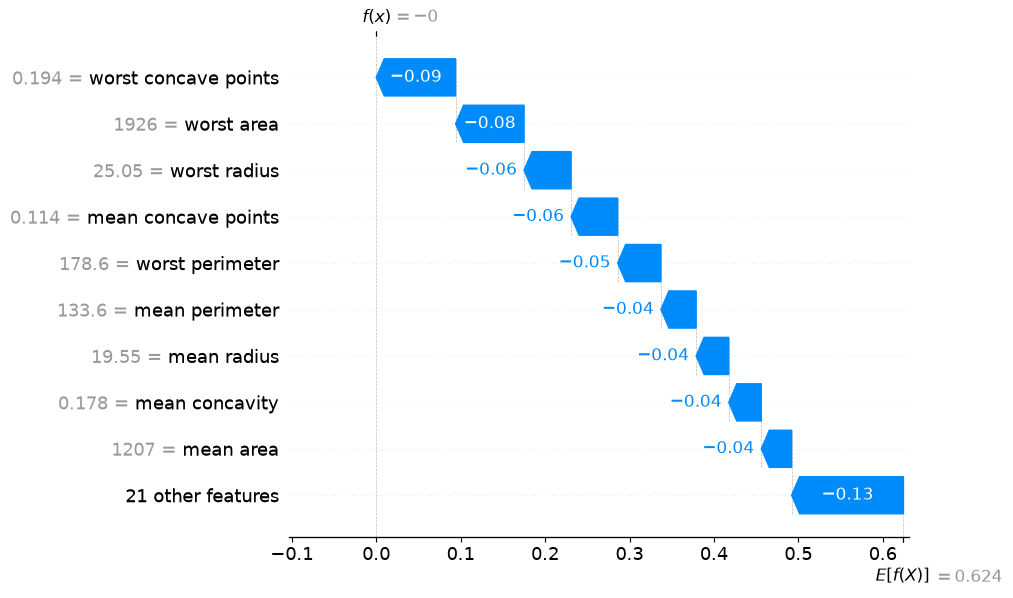

<Figure size 640x480 with 0 Axes>

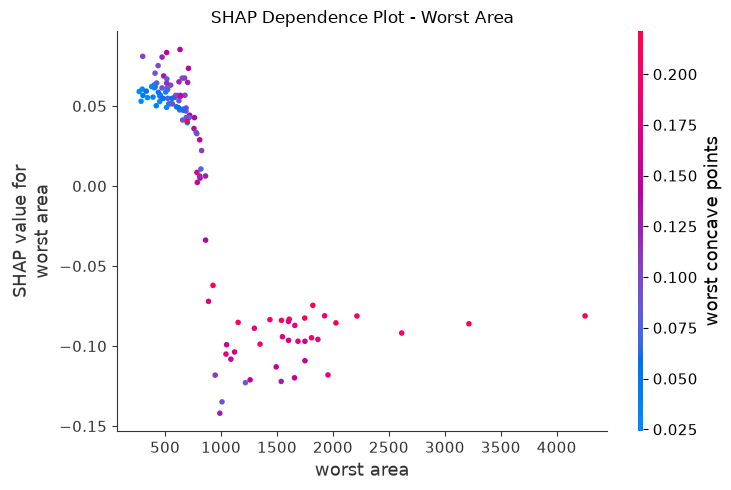

In [33]:
# TASK 11: Compare Different SHAP Plots

# 1. Bar Plot - Global Feature Importance
plt.figure()
shap.plots.bar(shap_values_class, max_display=10, show=False)
plt.title("SHAP Bar Plot - Global Importance")
plt.tight_layout()
plt.show()

# 2. Beeswarm Plot - Importance and Direction
plt.figure()
shap.plots.beeswarm(shap_values_class, max_display=10, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

# 3. Waterfall Plot - Individual Prediction
sample_index = 0
shap.plots.waterfall(
    shap_values_class[sample_index],
    max_display=10
)

# 4. Force Plot - Individual Feature Contributions
shap.initjs()
shap.force_plot(
    shap_values_class.base_values[sample_index],
    shap_values_class.values[sample_index],
    X_test.iloc[sample_index],
    feature_names=X_test.columns
)

# 5. Dependence Plot - Feature Value vs SHAP Value
plt.figure()
shap.dependence_plot(
    "worst area",
    shap_values_class.values,
    X_test,
    interaction_index="auto",
    show=False
)
plt.title("SHAP Dependence Plot - Worst Area")
plt.tight_layout()
plt.show()

12. Global Explanation: The SHAP bar and beeswarm plots show how the model generally classifies breast tumour samples. Features such as worst area, worst concave points, worst radius, worst perimeter, and mean concave points have the greatest overall influence on the predictions.

Local Explanation: The SHAP waterfall and force plots explain why the model classified one particular tumour sample as malignant or benign. For example, Sample 0 was correctly classified as malignant. The individual feature contributions show how the prediction moved from the base value toward the final classification.

Therefore, global explanations describe the overall behaviour of the model, while local explanations describe the reasoning behind an individual prediction. Both are important for understanding and interpreting the model.

<Figure size 640x480 with 0 Axes>

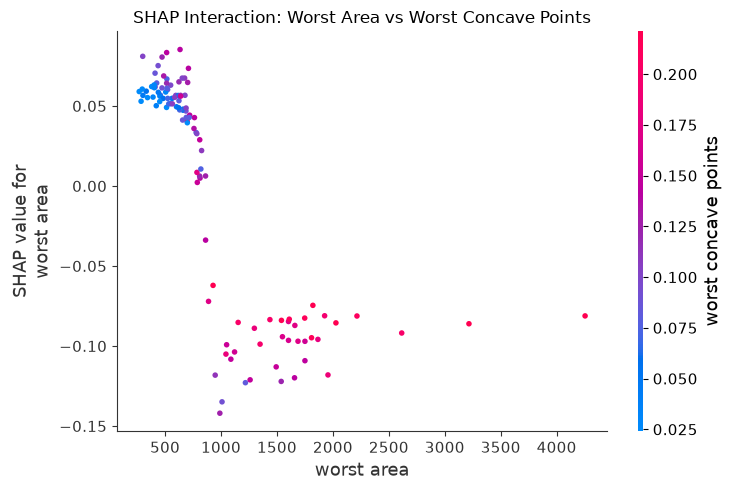

In [34]:
# TASK 13: Analyse Feature Interactions

# Analyze interaction between two important features
plt.figure()

shap.dependence_plot(
    "worst area",
    shap_values_class.values,
    X_test,
    interaction_index="worst concave points",
    show=False
)

plt.title("SHAP Interaction: Worst Area vs Worst Concave Points")
plt.tight_layout()
plt.show()

The SHAP dependence plot shows a possible interaction between worst area and worst concave points. The effect of worst area on the prediction can change depending on the value of worst concave points. This indicates that the model may consider the combined effect of these features rather than treating each feature independently. Feature interactions are important because they help explain more complex model behaviour and can reveal relationships that are not visible from individual feature importance alone.

In [35]:
# TASK 14: SHAP-Based Model Analysis

# Display the five most important features
print("Five Most Important Features:")
display(feature_importance.head(5))

# Find strongest positive and negative SHAP contributions
max_positive = shap_values_class.values.max()
max_negative = shap_values_class.values.min()

positive_position = np.unravel_index(
    np.argmax(shap_values_class.values),
    shap_values_class.values.shape
)

negative_position = np.unravel_index(
    np.argmin(shap_values_class.values),
    shap_values_class.values.shape
)

print("Strongest Positive Contribution:")
print(
    X_test.columns[positive_position[1]],
    "->",
    max_positive
)

print("\nStrongest Negative Contribution:")
print(
    X_test.columns[negative_position[1]],
    "->",
    max_negative
)

Five Most Important Features:


,Feature,Mean Absolute SHAP
23,worst area,0.066893
27,worst concave points,0.063026
20,worst radius,0.048655
22,worst perimeter,0.045389
7,mean concave points,0.041439


Strongest Positive Contribution:
worst area -> 0.08527025199274453

Strongest Negative Contribution:
worst concave points -> -0.20975312279308633


The five most important features identified by SHAP are worst area, worst concave points, worst radius, worst perimeter, and mean concave points. SHAP also identifies features that have strong positive or negative contributions for individual predictions. The dependence plots show that some features can have nonlinear effects, while the interaction analysis indicates that the effect of one feature can depend on another feature. Features such as worst area and worst concave points consistently appear among the most influential features.

SHAP provides a deeper understanding than classification accuracy because accuracy only indicates how many predictions are correct. SHAP explains which features influenced the predictions, the direction of their effects, and why individual samples were classified in a particular way. This provides both global and local insight into the model's behaviour.

Misclassified sample indices: [ 3 25 35 53 65]

Selected Misclassified Sample: 3
Actual Class: benign
Predicted Class: malignant
Prediction Probability: [0.72 0.28]


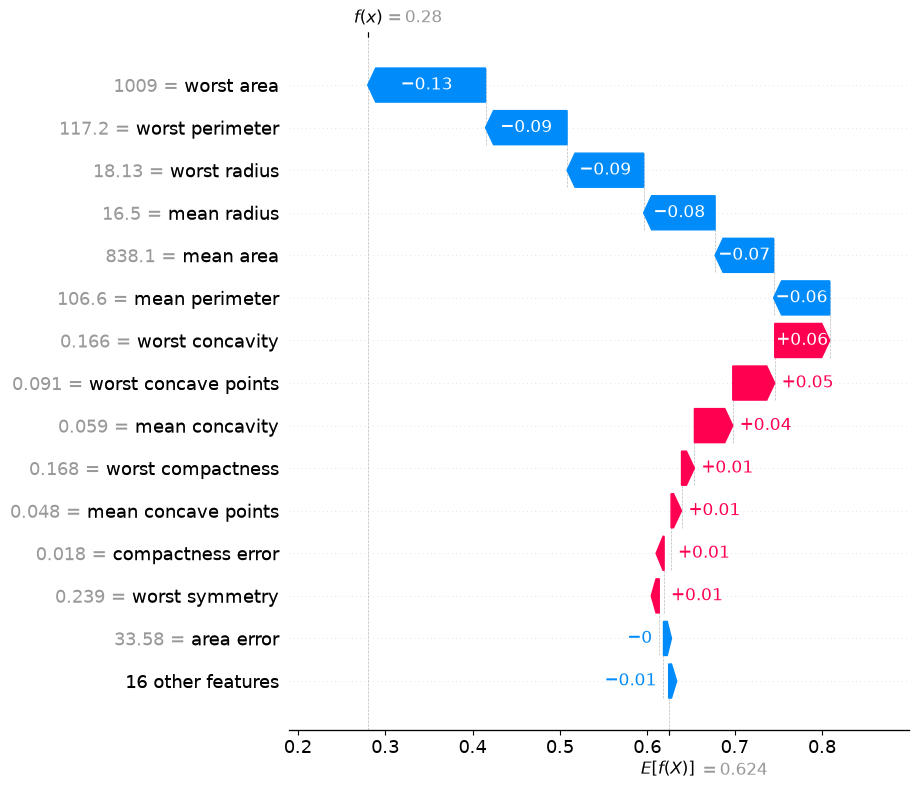

In [36]:
# TASK 15: Explain a Misclassified Sample

# Find incorrectly classified test samples
misclassified_indices = np.where(y_test.values != y_pred)[0]

print("Misclassified sample indices:", misclassified_indices)

# Select the first misclassified sample
sample_index = misclassified_indices[0]

print("\nSelected Misclassified Sample:", sample_index)
print("Actual Class:", data.target_names[y_test.iloc[sample_index]])
print("Predicted Class:", data.target_names[y_pred[sample_index]])
print("Prediction Probability:", y_pred_proba[sample_index])

# Generate SHAP waterfall plot
shap.plots.waterfall(
    shap_values_class[sample_index],
    max_display=15
)

The selected sample was actually benign, but the model incorrectly predicted it as malignant with a probability of 72%. The SHAP waterfall plot shows that several features contributed to this incorrect prediction. Worst perimeter (-0.09), worst radius (-0.09), mean radius (-0.08), mean area (-0.07), and mean perimeter (-0.06) made strong contributions in the direction away from the explained benign class, while worst concavity (+0.06), worst concave points (+0.05), and mean concavity (+0.04) contributed in the opposite direction. Overall, the combined feature contributions caused the model to favour the malignant classification. This explanation reveals that the error was caused by the combined influence of several tumour measurements rather than a single feature.

Correctly classified sample indices: [  0   1   2   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  26  27  28  29  30  31  32  33  34  36  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  54  55  56  57
  58  59  60  61  62  63  64  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 113]

Selected Correctly Classified Sample: 0
Actual Class: malignant
Predicted Class: malignant
Prediction Probability: [1. 0.]


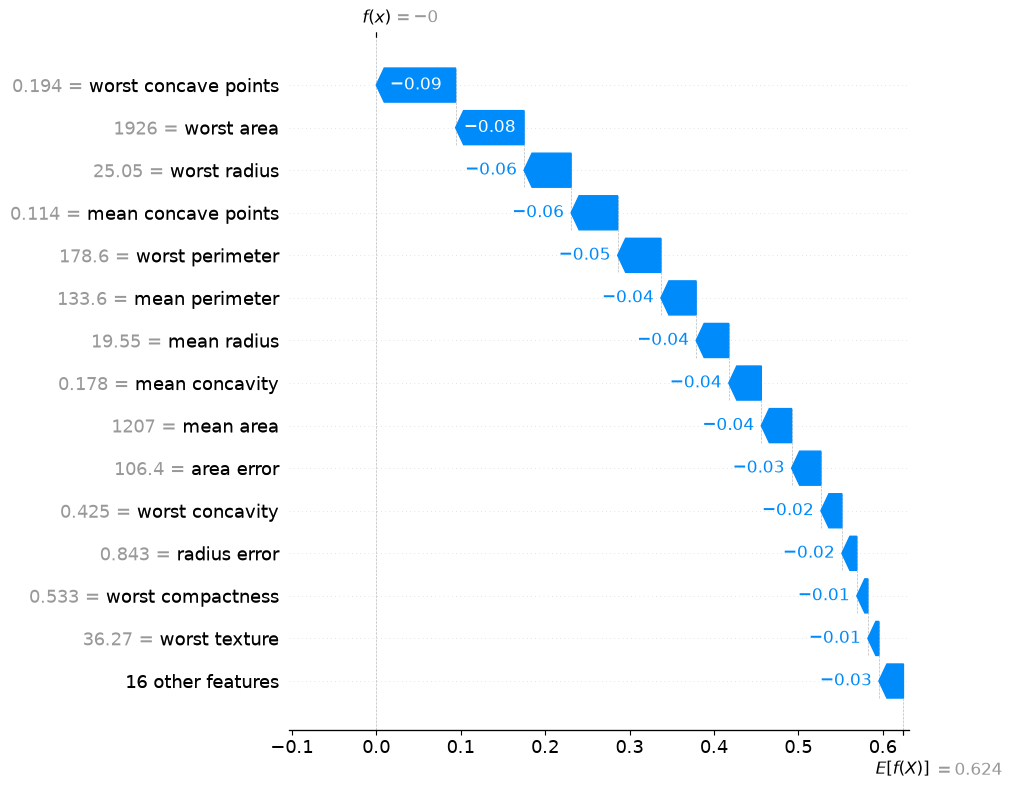

In [37]:
# TASK 16: Explain a Correctly Classified Sample

# Find correctly classified test samples
correct_indices = np.where(y_test.values == y_pred)[0]

print("Correctly classified sample indices:", correct_indices)

# Select the first correctly classified sample
correct_sample_index = correct_indices[0]

print("\nSelected Correctly Classified Sample:", correct_sample_index)
print("Actual Class:", data.target_names[y_test.iloc[correct_sample_index]])
print("Predicted Class:", data.target_names[y_pred[correct_sample_index]])
print("Prediction Probability:", y_pred_proba[correct_sample_index])

# Generate SHAP waterfall plot
shap.plots.waterfall(
    shap_values_class[correct_sample_index],
    max_display=15
)

The selected sample was malignant and the model correctly predicted it as malignant, with a prediction probability of 100% for malignant. The SHAP waterfall plot shows the individual feature contributions that influenced this prediction. The features with negative SHAP values for the explained benign class pushed the prediction away from benign and toward malignant, while positive contributions pushed in the opposite direction. Compared with the misclassified sample in Task 15, the important feature contributions in this sample collectively supported the correct malignant classification. This shows how SHAP can explain why the model made a correct prediction and how individual feature contributions affect the final decision.

Final Observation 
Conclusion: SHAP provides both global and local explanations for the trained machine learning model used for breast cancer classification. The global SHAP plots help identify the most important features and show how these features generally influence the model's predictions. Local explanations such as waterfall and force plots show how individual feature values contribute to the prediction of a particular tumour sample. SHAP also helps understand feature interactions, differences between individual samples, and the reasons behind correct and incorrect predictions. Therefore, SHAP provides more detailed insight into model behaviour than classification accuracy alone. However, SHAP explanations should be interpreted carefully and validated by domain experts, especially in healthcare applications, because an explanation does not guarantee that the model's decision is medically correct.